# **MODELO MLP - TRABAJO FINAL**
**Apellidos y Nombre:** Vasquez Caiza Juan Marcelo.

**Carrera:** Ingenieria de Sistemas.

**Repositorio:** https://github.com/Juan55XXD/SIS420-Inteligencia-Artificial-I-/tree/main/Laboratorios/Proyecto

In [226]:
#Librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Librerias para Pytorch
import torch
import torch.nn as nn
import torch.optim as optim

import random

# **Preparacion de Datos**

In [227]:
data = pd.read_csv('dataset.csv', delimiter=',')
print('INFORMACION DE TIPO DE DATOS')
data.info()
print('\nDATOS VACIOS')
print(pd.isnull(data).sum())

INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360000 entries, 0 to 359999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             360000 non-null  object 
 1   Producto          360000 non-null  object 
 2   Categoría         360000 non-null  object 
 3   Precio            360000 non-null  float64
 4   UnidadesVendidas  360000 non-null  int64  
 5   Descuento         360000 non-null  int64  
 6   Mes               360000 non-null  int64  
 7   Día_Semana        360000 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 22.0+ MB

DATOS VACIOS
Fecha               0
Producto            0
Categoría           0
Precio              0
UnidadesVendidas    0
Descuento           0
Mes                 0
Día_Semana          0
dtype: int64


In [228]:
print(data)

             Fecha                   Producto Categoría  Precio  \
0       21/01/2023           Leche Pil UHT 1L   Lácteos    7.25   
1       04/01/2023        Leche Pil Entera 1L   Lácteos    8.58   
2       01/01/2023       Mantequilla Pil 200g  Derivado   12.01   
3       24/01/2023           Leche Pil UHT 1L   Lácteos    7.40   
4       09/01/2023         Leche Pil Light 1L   Lácteos    8.84   
...            ...                        ...       ...     ...   
359995  23/12/2023  Leche Pil Deslactosada 1L   Lácteos    9.24   
359996  09/12/2023    Leche Pil En Polvo 500g   Lácteos   24.07   
359997  05/12/2023        Leche Pil Entera 1L   Lácteos    8.77   
359998  14/12/2023   Yogurt Bebible Pil 200ml  Derivado    4.45   
359999  01/12/2023        Leche Pil Entera 1L   Lácteos    9.06   

        UnidadesVendidas  Descuento  Mes  Día_Semana  
0                    115          0    1           6  
1                    127          5    1           3  
2                     19      

In [229]:
data['Fecha'] = pd.to_datetime(data['Fecha'], dayfirst=True)
data = pd.get_dummies(data, columns=['Producto','Categoría'])
print(data)

            Fecha  Precio  UnidadesVendidas  Descuento  Mes  Día_Semana  \
0      2023-01-21    7.25               115          0    1           6   
1      2023-01-04    8.58               127          5    1           3   
2      2023-01-01   12.01                19          0    1           7   
3      2023-01-24    7.40               113         20    1           2   
4      2023-01-09    8.84                78          0    1           1   
...           ...     ...               ...        ...  ...         ...   
359995 2023-12-23    9.24                88          0   12           6   
359996 2023-12-09   24.07                25         10   12           6   
359997 2023-12-05    8.77               119          5   12           2   
359998 2023-12-14    4.45                87          0   12           4   
359999 2023-12-01    9.06               110          0   12           5   

        Producto_Bebida Láctea Pil Chocolate 1L  Producto_Crema Pil 200ml  \
0                     

In [230]:
X = data.drop(columns=['Fecha', 'UnidadesVendidas'])
y = data['UnidadesVendidas']
columnas_modelo = X.columns #consistencia de las caracteristicas y guardar entradas
print(X)

        Precio  Descuento  Mes  Día_Semana  \
0         7.25          0    1           6   
1         8.58          5    1           3   
2        12.01          0    1           7   
3         7.40         20    1           2   
4         8.84          0    1           1   
...        ...        ...  ...         ...   
359995    9.24          0   12           6   
359996   24.07         10   12           6   
359997    8.77          5   12           2   
359998    4.45          0   12           4   
359999    9.06          0   12           5   

        Producto_Bebida Láctea Pil Chocolate 1L  Producto_Crema Pil 200ml  \
0                                         False                     False   
1                                         False                     False   
2                                         False                     False   
3                                         False                     False   
4                                         False               

# **Division de datos**

In [231]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Estandarizacion de datos**

In [232]:
from sklearn.preprocessing import StandardScaler
#Garantizar que los datos de entrada y salida estén en una escala uniforme
#Estandarizacion de X
scaler_X = StandardScaler()

#ajustar solo en X_train
X_train_scaled = scaler_X.fit_transform(X_train)

#transformar X_test(SIN re-ajustar)
X_test_scaled = scaler_X.transform(X_test)



#Estandarizacion de Y
scaler_y = StandardScaler()

# (Necesita .values.reshape(-1, 1) porque es una Serie de Pandas)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

#Transformar y_test (SIN re-ajustar)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [233]:
X_train_scaled.shape[1]

21

# **Tensores**

In [234]:
torch.cuda.is_available()

True

In [235]:
#Entrenamiento
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).cuda()
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1).cuda()

#Test
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).cuda()
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1).cuda()

# **Modelo MLP**

In [236]:
class MLP(nn.Module):
    #constructor
    def __init__(self, D_in, H1, H2, D_out):

        #llamamos al constructor de la clase madre
        super(MLP, self).__init__()

        #definicion de capas
        self.hidden1 = nn.Linear(D_in, H1)    #capa oculta 1
        self.hidden2 = nn.Linear(H1, H2)      #capa oculta 2
        self.output = nn.Linear(H2, D_out)    #capa de salida
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x)) #relu no linealidad en el modelo, aprendizaje de patrrones complejos
        x = self.output(x)
        return x

Inicializacion del modelo

In [237]:
#iniciamos el modelo
D_in = X_train_scaled.shape[1] 
H1 = 64
H2 = 32
D_out = 1

model = MLP(D_in, H1, H2, D_out)

#codigo para saber si el modelo esta votando los datos en las cantidades correctas
x_prueba = torch.randn(500, D_in)
print(x_prueba)
outputs = model(x_prueba)
outputs.shape

tensor([[-0.8654, -1.2854,  0.0930,  ...,  0.1234, -0.1109, -1.2867],
        [ 0.5507,  0.2197,  0.5519,  ...,  0.1500, -0.0083,  1.6560],
        [ 0.4232, -0.6005,  0.4785,  ..., -1.5568,  0.3939,  0.8719],
        ...,
        [ 1.5079,  0.0954, -0.2892,  ...,  1.1832,  0.3606,  0.8069],
        [-0.2933, -1.2281, -0.2463,  ...,  0.4191,  0.2417, -1.4760],
        [ 1.5144,  0.7639,  0.6077,  ..., -1.3351, -0.1506, -0.6988]])


torch.Size([500, 1])

Definir la funcion de **perdida** y el **optimizador**.

In [238]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **Entrenamiento**

In [239]:
model.to("cuda")
epochs = 2700
log_each = 10
l = []
model.train()

for e in range(1, epochs+1):

    #forward
    y_pred = model(X_train_tensor)

    #loss
    loss = criterion(y_pred, y_train_tensor)
    l.append(loss.item())

    #ponemos a cero los gradientes
    optimizer.zero_grad()

    #backprop calculamos todos los gradientes automaticamente
    loss.backward()

    #update de los pesos
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

Epoch 10/2700 Loss 0.88639
Epoch 20/2700 Loss 0.75160
Epoch 30/2700 Loss 0.62636
Epoch 40/2700 Loss 0.52637
Epoch 50/2700 Loss 0.45712
Epoch 60/2700 Loss 0.40874
Epoch 70/2700 Loss 0.37324
Epoch 80/2700 Loss 0.34616
Epoch 90/2700 Loss 0.32481
Epoch 100/2700 Loss 0.30756
Epoch 110/2700 Loss 0.29334
Epoch 120/2700 Loss 0.28137
Epoch 130/2700 Loss 0.27115
Epoch 140/2700 Loss 0.26230
Epoch 150/2700 Loss 0.25454
Epoch 160/2700 Loss 0.24765
Epoch 170/2700 Loss 0.24147
Epoch 180/2700 Loss 0.23589
Epoch 190/2700 Loss 0.23081
Epoch 200/2700 Loss 0.22616
Epoch 210/2700 Loss 0.22187
Epoch 220/2700 Loss 0.21790
Epoch 230/2700 Loss 0.21420
Epoch 240/2700 Loss 0.21075
Epoch 250/2700 Loss 0.20750
Epoch 260/2700 Loss 0.20444
Epoch 270/2700 Loss 0.20155
Epoch 280/2700 Loss 0.19881
Epoch 290/2700 Loss 0.19619
Epoch 300/2700 Loss 0.19371
Epoch 310/2700 Loss 0.19133
Epoch 320/2700 Loss 0.18906
Epoch 330/2700 Loss 0.18689
Epoch 340/2700 Loss 0.18481
Epoch 350/2700 Loss 0.18281
Epoch 360/2700 Loss 0.18090
E

# **Evaluacion**

In [240]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor) #Predicciones escaladas

In [241]:
# Revertir predicciones
y_pred_reales = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy())

# Revertir valores reales de prueba (para comparar)
y_test_reales = scaler_y.inverse_transform(y_test_scaled) # o puedes usar y_test.values

In [242]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#RMSE
rmse = np.sqrt(mean_squared_error(y_test_reales, y_pred_reales))
print(f"El error promedio del modelo es de +/- {rmse:.2f} unidades.")

El error promedio del modelo es de +/- 9.02 unidades.


In [243]:
#MAE
mae = mean_absolute_error(y_test_reales, y_pred_reales)
print(f"Error Absoluto Medio (MAE): {mae:.4f} unidades")

Error Absoluto Medio (MAE): 7.0757 unidades


In [244]:
#R2
r2 = r2_score(y_test_reales, y_pred_reales)
print(f"Coeficiente R-cuadrado (R²): {r2:.4f}")

Coeficiente R-cuadrado (R²): 0.9123


# **Graficacion**

In [245]:
#Creamos un DataFrame de pandas para la comparación
df_evaluacion = pd.DataFrame({
    'Ventas_Reales': y_test_reales.flatten(),
    'Ventas_Predichas': y_pred_reales.flatten()
})

#Redondeo
df_evaluacion['Ventas_Predichas'] = df_evaluacion['Ventas_Predichas'].round(0)

#Calcular la columna de Error Absoluto para cada predicción
df_evaluacion['Error_Absoluto'] = (df_evaluacion['Ventas_Predichas'] - df_evaluacion['Ventas_Reales']).abs()

#Ordenar por el error para ver los peores casos
df_evaluacion_ordenada = df_evaluacion.sort_values(by='Error_Absoluto', ascending=False)


#Tablas
print("--- Comparación de Predicciones vs Reales (Muestra de 20 filas) ---")
print(df_evaluacion.head(20))
print("\n" + "="*50 + "\n")
print("--- Las 10 Peores Predicciones (Mayor Error Absoluto) ---")
print(df_evaluacion_ordenada.head(10))

--- Comparación de Predicciones vs Reales (Muestra de 20 filas) ---
    Ventas_Reales  Ventas_Predichas  Error_Absoluto
0            50.0              48.0             2.0
1            60.0              60.0             0.0
2            85.0              80.0             5.0
3            39.0              37.0             2.0
4            76.0              71.0             5.0
5            94.0              94.0             0.0
6            88.0              92.0             4.0
7            73.0              69.0             4.0
8            97.0             108.0            11.0
9            98.0              90.0             8.0
10           62.0              55.0             7.0
11          107.0              99.0             8.0
12           75.0              70.0             5.0
13          108.0              93.0            15.0
14           61.0              67.0             6.0
15           87.0              87.0             0.0
16           34.0              26.0             

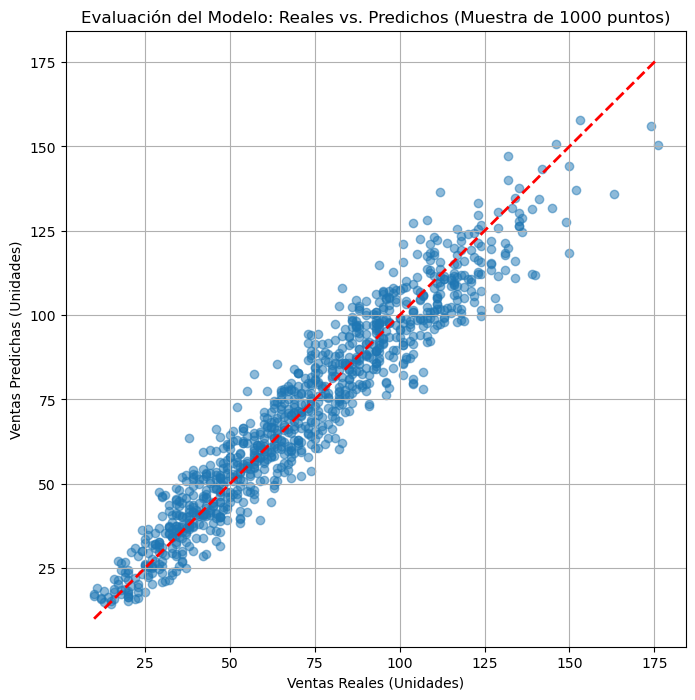

In [246]:
#Aplanamos los arrays para que el gráfico funcione bien
y_test_flat = y_test_reales.flatten()
y_pred_flat = y_pred_reales.flatten()

#Tomamos una muestra aleatoria de 1000 puntos para no saturar el gráfico
indices = np.random.choice(len(y_test_flat), 1000, replace=False)
y_test_sample = y_test_flat[indices]
y_pred_sample = y_pred_flat[indices]


plt.figure(figsize=(8, 8))
plt.scatter(y_test_sample, y_pred_sample, alpha=0.5)
plt.xlabel("Ventas Reales (Unidades)")
plt.ylabel("Ventas Predichas (Unidades)")
plt.title("Evaluación del Modelo: Reales vs. Predichos (Muestra de 1000 puntos)")

#Añadimos una línea roja (y=x). 
min_val = min(y_test_sample.min(), y_pred_sample.min())
max_val = max(y_test_sample.max(), y_pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.grid(True)
plt.show()

# **Prediccion**

Nuevos Datos: Creamos un diccionario con los datos del dia que queremos predecir.

In [247]:
datos_nuevos = {
    'Precio': 8.50,         # Precio de ese día
    'Descuento': 5,         # Descuento de ese día
    'Mes': 10,              # Mes (ej. Octubre)
    'Día_Semana': 3,        # Día de la semana (ej. Miércoles)
    'Producto': 'Leche Pil Entera 1L', # El producto específico
    'Categoría': 'Lácteos'  # La categoría del producto
}

In [248]:
datos_df = pd.DataFrame([datos_nuevos])
print("1. Datos de entrada (como DataFrame):")
print(datos_df.head())
print("\n")

1. Datos de entrada (como DataFrame):
   Precio  Descuento  Mes  Día_Semana             Producto Categoría
0     8.5          5   10           3  Leche Pil Entera 1L   Lácteos




Aplicamos One-Hot Encoding.

In [249]:
datos_codificados = pd.get_dummies(datos_df, columns=['Producto', 'Categoría'])

Reindexar Columnas.

In [250]:
datos_procesados = datos_codificados.reindex(columns=columnas_modelo, fill_value=0)
print("2. Datos procesados (One-Hot Encoding y Reindexado):")
print(datos_procesados.head())
print("\n")

2. Datos procesados (One-Hot Encoding y Reindexado):
   Precio  Descuento  Mes  Día_Semana  \
0     8.5          5   10           3   

   Producto_Bebida Láctea Pil Chocolate 1L  Producto_Crema Pil 200ml  \
0                                        0                         0   

   Producto_Leche Condensada Pil 400g  Producto_Leche Pil 500ml (mini)  \
0                                   0                                0   

   Producto_Leche Pil Deslactosada 1L  Producto_Leche Pil En Polvo 500g  ...  \
0                                   0                                 0  ...   

   Producto_Leche Pil Light 1L  Producto_Leche Pil UHT 1L  \
0                            0                          0   

   Producto_Mantequilla Pil 200g  Producto_Queso Pil Fresco 300g  \
0                              0                               0   

   Producto_Yogurt Bebible Pil 200ml  Producto_Yogurt Pil Fresa 1L  \
0                                  0                             0   

   Produ

Estandarizar los datos.

In [251]:
datos_scaled = scaler_X.transform(datos_procesados)
print("3. Datos estandarizados (listos para el modelo)")
print(datos_scaled)
print("\n")

3. Datos estandarizados (listos para el modelo)
[[-0.15652037  0.41208846  1.01312678 -0.50317145 -0.24235099 -0.16822504
  -0.18892276 -0.30242865 -0.30228502 -0.1468427   2.50161238 -0.35411869
  -0.37808445 -0.20805163 -0.2260927  -0.32896288 -0.25874164 -0.27248867
  -0.24235099 -0.78557211  0.8811894 ]]




Predecir con el Modelo MLP.

In [252]:
model.eval() # Poner el modelo en modo de evaluación
with torch.no_grad(): # No necesitamos calcular gradientes
    
    # Convertir a tensor y mover a GPU
    tensor_nuevo = torch.tensor(datos_scaled, dtype=torch.float32).cuda()
    
    # Obtener la predicción (aún estará escalada)
    pred_scaled = model(tensor_nuevo)

Interpretar el Resultado.

In [253]:
pred_unidades = scaler_y.inverse_transform(pred_scaled.cpu().numpy())

unidades_predichas = pred_unidades[0][0]

print("--- 🚀 PREDICCIÓN FINAL 🚀 ---")
print(f"Para el producto '{datos_nuevos['Producto']}' con precio {datos_nuevos['Precio']}...")
print(f"Se espera vender: {unidades_predichas:.0f} unidades") # .0f para redondear

--- 🚀 PREDICCIÓN FINAL 🚀 ---
Para el producto 'Leche Pil Entera 1L' con precio 8.5...
Se espera vender: 108 unidades


Productos vendidos por Hora

SE creo una funcion para Predecir los dias que se solicitan

In [254]:
def predecir_mes_completo(producto, categoria, precio, descuento, mes, año=2025):
    fechas = pd.date_range(start=f'{año}-{mes}-25', end=f'{año}-{mes}-31')
    lista_dias = []

    for fecha in fechas:
        dia_semana = fecha.dayofweek + 1

        item = {
            'Precio': precio,
            'Descuento': descuento,
            'Mes': mes,
            'Día_Semana':dia_semana,
            'Producto': producto,
            'Categoría': categoria,
            'Fecha_Real': fecha.strftime('%Y-%m-%d')
        }
        lista_dias.append(item)

    df_mes = pd.DataFrame(lista_dias)

    #one hot encoding
    df_cod = pd.get_dummies(df_mes, columns=['Producto','Categoría'])
    #reindexacion
    df_proc = df_cod.reindex(columns=columnas_modelo, fill_value=0)

    X_scaled_m = scaler_X.transform(df_proc)

    #Prediccion
    model.eval()
    with torch.no_grad():
        tensor = torch.tensor(X_scaled_m, dtype=torch.float32).cuda()
        preds_scaled = model(tensor)
    
    preds_reales = scaler_y.inverse_transform(preds_scaled.cpu().numpy())
    #Mostrar resultados
    df_resultados = df_mes[['Fecha_Real','Día_Semana']].copy()
    df_resultados['Venta_Predicha'] = preds_reales.round(0)
    
    return df_resultados

In [255]:
print("--- Proyección de Ventas Diarias (Diciembre) ---")
tabla_diciembre = predecir_mes_completo(
    producto='Leche Pil Entera 1L',
    categoria='Lácteos',
    precio=8.50,
    descuento=0,
    mes=12
)
print(tabla_diciembre.head())

--- Proyección de Ventas Diarias (Diciembre) ---
   Fecha_Real  Día_Semana  Venta_Predicha
0  2025-12-25           4           124.0
1  2025-12-26           5           132.0
2  2025-12-27           6           144.0
3  2025-12-28           7           108.0
4  2025-12-29           1           114.0
